# Прогнозирование уровня глюкозы через 1 час

Сравниваются:

- последнее известное значение глюкозы;
- Ridge;
- HistGradientBoosting;
- CatBoost;
- Hybrid GRU: многомерная последовательность + дополнительные табличные признаки.

In [9]:
import re
import random
import copy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import TransformedTargetRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

from catboost import CatBoostRegressor

import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

In [10]:
SEED = 42
TARGET = "bg+1:00"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

train = pd.read_csv("data/train.csv", low_memory=False)

print(train.shape)
train[["id", "p_num", "time", TARGET]].head()

(177024, 508)


,id,p_num,time,bg+1:00
0,p01_0,p01,06:10:00,13.4
1,p01_1,p01,06:25:00,12.8
2,p01_2,p01,06:40:00,15.5
3,p01_3,p01,06:55:00,14.8
4,p01_4,p01,07:10:00,12.7


In [11]:
def lag_minutes(column):
    match = re.search(r"-(\d+):(\d+)$", column)
    if match is None:
        return None
    hours, minutes = map(int, match.groups())
    return hours * 60 + minutes


def lag_columns(df, prefix, max_minutes):
    columns = [
        column
        for column in df.columns
        if column.startswith(f"{prefix}-")
        and lag_minutes(column) is not None
        and lag_minutes(column) <= max_minutes
    ]
    return sorted(columns, key=lag_minutes)


def make_tabular_features(df):
    features = pd.DataFrame(index=df.index)

    parsed_time = pd.to_datetime(df["time"], format="%H:%M:%S")
    minute_of_day = parsed_time.dt.hour * 60 + parsed_time.dt.minute
    features["time_sin"] = np.sin(2 * np.pi * minute_of_day / 1440)
    features["time_cos"] = np.cos(2 * np.pi * minute_of_day / 1440)

    windows = {
        "bg": 120,
        "insulin": 180,
        "carbs": 180,
        "hr": 60,
        "steps": 60,
        "cals": 60,
    }

    for prefix, window in windows.items():
        columns = lag_columns(df, prefix, window)
        features[columns] = df[columns].apply(pd.to_numeric, errors="coerce")

    for window in (30, 60, 120, 360):
        columns = lag_columns(df, "bg", window)
        values = df[columns].apply(pd.to_numeric, errors="coerce")
        features[f"bg_mean_{window}m"] = values.mean(axis=1)
        features[f"bg_std_{window}m"] = values.std(axis=1)
        features[f"bg_min_{window}m"] = values.min(axis=1)
        features[f"bg_max_{window}m"] = values.max(axis=1)

    current_bg = lag_columns(df, "bg", 10)[0]
    current_values = pd.to_numeric(df[current_bg], errors="coerce")

    for window in (30, 60, 120):
        past_column = min(
            lag_columns(df, "bg", 360),
            key=lambda column: abs(lag_minutes(column) - window),
        )
        past_values = pd.to_numeric(df[past_column], errors="coerce")
        features[f"bg_delta_{window}m"] = current_values - past_values

    for prefix in ("insulin", "carbs", "steps", "cals"):
        for window in (30, 60, 180):
            columns = lag_columns(df, prefix, window)
            values = df[columns].apply(pd.to_numeric, errors="coerce")
            features[f"{prefix}_sum_{window}m"] = values.sum(axis=1, min_count=1)

    for window in (30, 60, 180):
        columns = lag_columns(df, "hr", window)
        values = df[columns].apply(pd.to_numeric, errors="coerce")
        features[f"hr_mean_{window}m"] = values.mean(axis=1)
        features[f"hr_std_{window}m"] = values.std(axis=1)

    return features.astype("float32")


valid_rows = train[TARGET].notna()

data = train.loc[valid_rows].reset_index(drop=True)
y = pd.to_numeric(data[TARGET]).astype("float32")
X = make_tabular_features(data)



C:\Users\Anastasiia\AppData\Local\Temp\ipykernel_3348\2288223827.py:39: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  features[columns] = df[columns].apply(pd.to_numeric, errors="coerce")
C:\Users\Anastasiia\AppData\Local\Temp\ipykernel_3348\2288223827.py:39: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  features[columns] = df[columns].apply(pd.to_numeric, errors="coerce")
C:\Users\Anastasiia\AppData\Local\Temp\ipykernel_3348\2288223827.py:39: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of cal

In [12]:
print(X.shape)

(177024, 177)


In [13]:
position = data.groupby("p_num", sort=False).cumcount()
group_size = data.groupby("p_num", sort=False)["p_num"].transform("size")
valid_start = (group_size * 0.8).astype(int)

valid_mask = position >= valid_start
train_mask = ~valid_mask

X_train = X.loc[train_mask]
X_valid = X.loc[valid_mask]
y_train = y.loc[train_mask]
y_valid = y.loc[valid_mask]

print(f"train: {len(X_train):,}")
print(f"valid: {len(X_valid):,}")

train: 141,616
valid: 35,408


In [14]:
def metrics(y_true, prediction):
    return {
        "RMSE": mean_squared_error(y_true, prediction) ** 0.5,
        "MAE": mean_absolute_error(y_true, prediction),
    }


results = {}
predictions = {}

current_bg_column = lag_columns(data, "bg", 10)[0]
baseline_prediction = (
    pd.to_numeric(data.loc[valid_mask, current_bg_column], errors="coerce")
    .fillna(y_train.median())
    .to_numpy()
)

results["Last value"] = metrics(y_valid, baseline_prediction)
predictions["Last value"] = baseline_prediction

In [15]:
ridge = TransformedTargetRegressor(
    regressor=make_pipeline(
        SimpleImputer(strategy="median"),
        StandardScaler(),
        Ridge(alpha=10.0),
    ),
    transformer=StandardScaler(),
)

ridge.fit(X_train, y_train)
ridge_prediction = ridge.predict(X_valid)

results["Ridge"] = metrics(y_valid, ridge_prediction)
predictions["Ridge"] = ridge_prediction

In [16]:
hist_gradient_boosting = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_iter=300,
    max_leaf_nodes=31,
    l2_regularization=1.0,
    random_state=SEED,
)

hist_gradient_boosting.fit(X_train, y_train)
hgb_prediction = hist_gradient_boosting.predict(X_valid)

results["HistGradientBoosting"] = metrics(y_valid, hgb_prediction)
predictions["HistGradientBoosting"] = hgb_prediction

In [17]:
catboost = CatBoostRegressor(
    loss_function="RMSE",
    eval_metric="RMSE",
    iterations=1200,
    depth=8,
    learning_rate=0.05,
    random_seed=SEED,
    allow_writing_files=False,
    verbose=100,
)

catboost.fit(
    X_train,
    y_train,
    eval_set=(X_valid, y_valid),
    early_stopping_rounds=100,
)

catboost_prediction = catboost.predict(X_valid)

results["CatBoost"] = metrics(y_valid, catboost_prediction)
predictions["CatBoost"] = catboost_prediction

0:	learn: 2.9076549	test: 2.9939406	best: 2.9939406 (0)	total: 48.3ms	remaining: 57.9s
100:	learn: 1.9040021	test: 2.0411182	best: 2.0411182 (100)	total: 4.94s	remaining: 53.8s
200:	learn: 1.8078577	test: 2.0026884	best: 2.0026884 (200)	total: 9.67s	remaining: 48.1s
300:	learn: 1.7285966	test: 1.9879824	best: 1.9879824 (300)	total: 14.5s	remaining: 43.3s
400:	learn: 1.6629756	test: 1.9779572	best: 1.9779572 (400)	total: 19.2s	remaining: 38.2s
500:	learn: 1.6087178	test: 1.9737602	best: 1.9737602 (500)	total: 23.8s	remaining: 33.3s
600:	learn: 1.5604033	test: 1.9718914	best: 1.9715930 (594)	total: 28.5s	remaining: 28.4s
700:	learn: 1.5178844	test: 1.9707958	best: 1.9704427 (697)	total: 33.2s	remaining: 23.7s
800:	learn: 1.4809617	test: 1.9716786	best: 1.9699750 (729)	total: 38.1s	remaining: 19s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 1.969975019
bestIteration = 729

Shrink model to first 730 iterations.


In [18]:
class HybridGRURegressor(nn.Module):
    def __init__(self, sequence_features, static_features):
        super().__init__()

        self.gru = nn.GRU(
            input_size=sequence_features,
            hidden_size=48,
            num_layers=1,
            batch_first=True,
        )

        self.static_branch = nn.Sequential(
            nn.Linear(static_features, 32),
            nn.ReLU(),
        )

        self.head = nn.Sequential(
            nn.Linear(48 + 32, 32),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(32, 1),
        )

    def forward(self, sequence, static):
        _, hidden = self.gru(sequence)
        sequence_embedding = hidden[-1]
        static_embedding = self.static_branch(static)

        combined = torch.cat(
            [sequence_embedding, static_embedding],
            dim=1,
        )

        return self.head(combined)

In [19]:
sequence_prefixes = ["bg", "insulin", "carbs", "hr", "steps", "cals"]
sequence_lags = sorted(
    [lag_minutes(column) for column in lag_columns(data, "bg", 120)],
    reverse=True,
)


def closest_column(df, prefix, lag):
    columns = lag_columns(df, prefix, 360)
    return min(columns, key=lambda column: abs(lag_minutes(column) - lag))


sequence_channels = []

for prefix in sequence_prefixes:
    columns = [
        closest_column(data, prefix, lag)
        for lag in sequence_lags
    ]

    values = (
        data[columns]
        .apply(pd.to_numeric, errors="coerce")
        .to_numpy(dtype="float32")
    )

    train_values = values[train_mask.to_numpy()]
    valid_values = values[valid_mask.to_numpy()]

    if prefix in ("bg", "hr"):
        medians = np.nanmedian(train_values, axis=0)
        train_values = np.where(np.isnan(train_values), medians, train_values)
        valid_values = np.where(np.isnan(valid_values), medians, valid_values)
    else:
        train_values = np.nan_to_num(train_values, nan=0.0)
        valid_values = np.nan_to_num(valid_values, nan=0.0)

    sequence_channels.append((train_values, valid_values))


sequence_train = np.stack(
    [channel[0] for channel in sequence_channels],
    axis=-1,
)
sequence_valid = np.stack(
    [channel[1] for channel in sequence_channels],
    axis=-1,
)

sequence_mean = sequence_train.mean(axis=(0, 1), keepdims=True)
sequence_std = sequence_train.std(axis=(0, 1), keepdims=True) + 1e-6

sequence_train = (sequence_train - sequence_mean) / sequence_std
sequence_valid = (sequence_valid - sequence_mean) / sequence_std


static_columns = [
    column
    for column in X.columns
    if lag_minutes(column) is None
]

static_imputer = SimpleImputer(strategy="median")
static_scaler = StandardScaler()

static_train = static_imputer.fit_transform(X_train[static_columns])
static_valid = static_imputer.transform(X_valid[static_columns])

static_train = static_scaler.fit_transform(static_train).astype("float32")
static_valid = static_scaler.transform(static_valid).astype("float32")


target_mean = y_train.mean()
target_std = y_train.std()

y_train_scaled = (
    (y_train.to_numpy() - target_mean) / target_std
).astype("float32")

y_valid_scaled = (
    (y_valid.to_numpy() - target_mean) / target_std
).astype("float32")


train_dataset = TensorDataset(
    torch.tensor(sequence_train, dtype=torch.float32),
    torch.tensor(static_train, dtype=torch.float32),
    torch.tensor(y_train_scaled[:, None], dtype=torch.float32),
)

valid_dataset = TensorDataset(
    torch.tensor(sequence_valid, dtype=torch.float32),
    torch.tensor(static_valid, dtype=torch.float32),
    torch.tensor(y_valid_scaled[:, None], dtype=torch.float32),
)

train_loader = DataLoader(
    train_dataset,
    batch_size=512,
    shuffle=True,
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=1024,
    shuffle=False,
)

In [20]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

hybrid_gru = HybridGRURegressor(
    sequence_features=len(sequence_prefixes),
    static_features=len(static_columns),
).to(device)

optimizer = torch.optim.Adam(
    hybrid_gru.parameters(),
    lr=1e-3,
    weight_decay=1e-5,
)

loss_function = nn.MSELoss()

best_valid_loss = float("inf")
best_state = None

for epoch in range(15):
    hybrid_gru.train()
    train_loss = 0.0

    for batch_sequence, batch_static, batch_target in train_loader:
        batch_sequence = batch_sequence.to(device)
        batch_static = batch_static.to(device)
        batch_target = batch_target.to(device)

        optimizer.zero_grad()

        prediction = hybrid_gru(
            batch_sequence,
            batch_static,
        )

        loss = loss_function(
            prediction,
            batch_target,
        )

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * len(batch_sequence)

    hybrid_gru.eval()
    valid_loss = 0.0
    with torch.no_grad():
        for batch_sequence, batch_static, batch_target in valid_loader:
            batch_sequence = batch_sequence.to(device)
            batch_static = batch_static.to(device)
            batch_target = batch_target.to(device)

            prediction = hybrid_gru(
                batch_sequence,
                batch_static,
            )

            loss = loss_function(
                prediction,
                batch_target,
            )

            valid_loss += loss.item() * len(batch_sequence)

    train_loss /= len(train_dataset)
    valid_loss /= len(valid_dataset)

    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        best_state = copy.deepcopy(hybrid_gru.state_dict())

    print(
        f"epoch {epoch + 1:02d}: "
        f"train={train_loss:.4f}, "
        f"valid={valid_loss:.4f}"
    )


hybrid_gru.load_state_dict(best_state)
hybrid_gru.eval()

with torch.no_grad():
    hybrid_prediction_scaled = hybrid_gru(
        torch.tensor(sequence_valid, dtype=torch.float32).to(device),
        torch.tensor(static_valid, dtype=torch.float32).to(device),
    ).cpu().numpy().ravel()

hybrid_prediction = (
    hybrid_prediction_scaled * target_std + target_mean
)

results["Hybrid GRU"] = metrics(
    y_valid,
    hybrid_prediction,
)

predictions["Hybrid GRU"] = hybrid_prediction

epoch 01: train=0.5031, valid=0.4760
epoch 02: train=0.4391, valid=0.4635
epoch 03: train=0.4257, valid=0.4579
epoch 04: train=0.4175, valid=0.4561
epoch 05: train=0.4119, valid=0.4604
epoch 06: train=0.4069, valid=0.4510
epoch 07: train=0.4019, valid=0.4507
epoch 08: train=0.3982, valid=0.4485
epoch 09: train=0.3935, valid=0.4532
epoch 10: train=0.3897, valid=0.4495
epoch 11: train=0.3854, valid=0.4474
epoch 12: train=0.3813, valid=0.4476
epoch 13: train=0.3777, valid=0.4493
epoch 14: train=0.3735, valid=0.4533
epoch 15: train=0.3694, valid=0.4572


In [21]:
results_table = (
    pd.DataFrame(results)
    .T
    .sort_values("RMSE")
    .round(3)
)

results_table

,RMSE,MAE
CatBoost,1.970,1.463
HistGradientBoosting,1.989,1.473
Hybrid GRU,1.992,1.484
Ridge,2.116,1.588
Last value,2.435,1.790


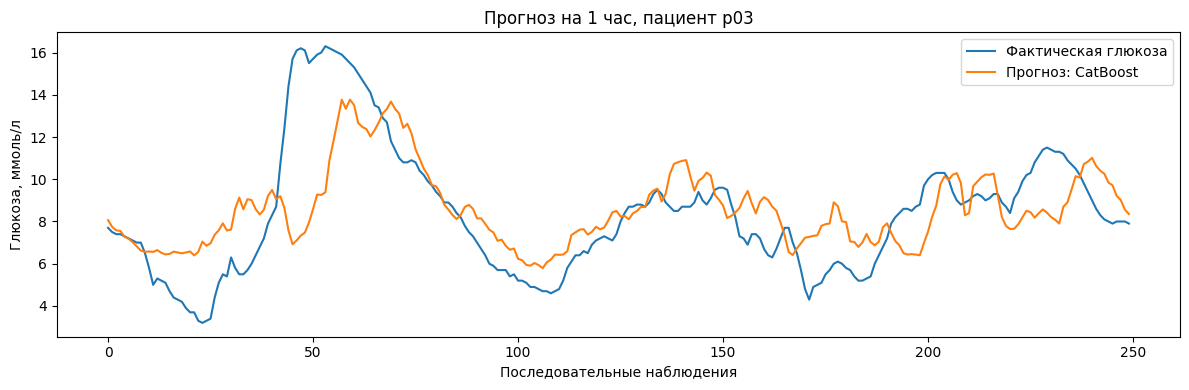

In [22]:
best_model_name = results_table.index[0]

validation_view = data.loc[valid_mask, ["p_num"]].copy()
validation_view["actual"] = y_valid.to_numpy()
validation_view["prediction"] = predictions[best_model_name]

patient = validation_view["p_num"].value_counts().idxmax()
fragment = validation_view[validation_view["p_num"] == patient].head(250)

plt.figure(figsize=(12, 4))
plt.plot(fragment["actual"].to_numpy(), label="Фактическая глюкоза")
plt.plot(
    fragment["prediction"].to_numpy(),
    label=f"Прогноз: {best_model_name}",
)
plt.xlabel("Последовательные наблюдения")
plt.ylabel("Глюкоза, ммоль/л")
plt.title(f"Прогноз на 1 час, пациент {patient}")
plt.legend()
plt.tight_layout()
plt.show()